# <span style="color:black; font-weight:bold;">DLPFC multi-slices alignment Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.24.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.24.2026
+ <span style="color:black; font-weight:bold;">Download</span>: DLPFC multi-slices data used in the tutorial are available at [151673_shuffled_round1.h5ad](https://drive.google.com/file/d/1Lgkkl7M1x8sBjdmwEfEV8yw15kyQsbLJ/view?usp=sharing) , [151674_shuffled_round1.h5ad](https://drive.google.com/file/d/14t7gs2vSbS3YrIbj2maoBzK7YFzQTIcB/view?usp=sharing), [151675_shuffled_round1.h5ad](https://drive.google.com/file/d/1VAaFhgCP5vpMVpgzECeyep42wkodNBUM/view?usp=sharing) and [151676_shuffled_round1.h5ad](https://drive.google.com/file/d/10kkkgZgxvyrObxEm7Tga2Ywt9uWb2USi/view?usp=sharing).
In this tutorial we apply MAPS to align DLPFC multi-slices dataset. We provide two multi-slice alignment schemes, namely sequential alignment and reference alignment.

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">151673(ST)</span>: 3611 spots and 33,538 genes   
+ <span style="color:black; font-weight:bold;">151674(ST)</span>: 3635 spots and 33,538 genes  
+ <span style="color:black; font-weight:bold;">151675(ST)</span>: 3566 spots and 33,538 genes   
+ <span style="color:black; font-weight:bold;">151676(ST)</span>: 3431 spots and 33,538 genes 

In [1]:
from MAPS.align import Multi_slices_rigid_alignment
from MAPS.utils import set_seed
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading DLPFC multi-slices data</span>

In [4]:
adata1=sc.read_h5ad('/home/dbj/LPcross/Data/DLPFCS_processed/round_1/151673_shuffled_round1.h5ad')
adata1.obs['batch']='151673'

adata2=sc.read_h5ad('/home/dbj/LPcross/Data/DLPFCS_processed/round_1/151674_shuffled_round1.h5ad')
adata2.obs['batch']='151674'

adata3=sc.read_h5ad('/home/dbj/LPcross/Data/DLPFCS_processed/round_1/151675_shuffled_round1.h5ad')
adata3.obs['batch']='151675'

adata4=sc.read_h5ad('/home/dbj/LPcross/Data/DLPFCS_processed/round_1/151676_shuffled_round1.h5ad')
adata4.obs['batch']='151676'

## <span style="color:black; font-weight:bold;">Spatial mapping of the DLPFC before alignment</span>

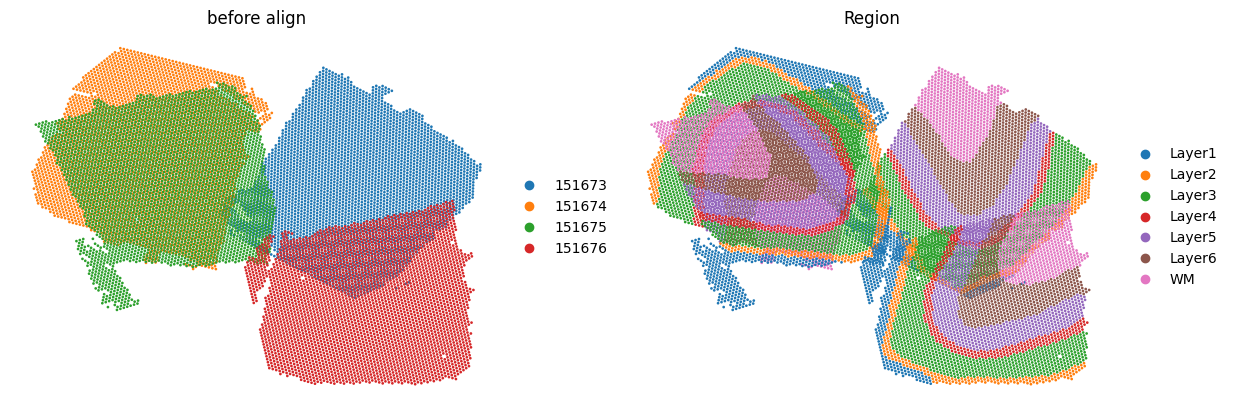

In [5]:
adata_list=[adata1,adata2,adata3,adata4]
adata=sc.concat(adata_list,join='inner')

sc.pl.embedding(adata=adata, basis='spatial',color=['batch','Region'],title='before align',size=15,frameon=False)

## <span style="color:black; font-weight:bold;">Sequential align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'sequential' The slices are aligned in the order adata_list

### <span style="color:black; font-weight:bold;">Output</span>   
sequential_list: A list of slices aligned in order

In [6]:
sequential_list = Multi_slices_rigid_alignment(adata_list, mode='sequential',epochs=500, sample_size=1000, enable_scale=False, device=device)


--- Slice 1 is the first slice ---

--- Aligning Slice 2 to Slice 1 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 500/500 [00:01<00:00, 350.82it/s, Loss=116.46, Scale=1.000, Rot=164.64°, Trans=(7675.6, -1447.1)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 165.01°, Translation (x, y): (7674.46, -1447.39)

--- Aligning Slice 3 to Slice 2 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████████| 500/500 [00:00<00:00, 523.80it/s, Loss=130.40, Scale=1.000, Rot=-46.42°, Trans=(7172.9, -140.9)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -48.34°, Translation (x, y): (7174.40, -138.99)

--- Aligning Slice 4 to Slice 3 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████| 500/500 [00:00<00:00, 536.75it/s, Loss=120.22, Scale=1.000, Rot=49.42°, Trans=(-336.4, 5387.4)]

Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 49.29°, Translation (x, y): (-334.04, 5386.01)

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">Spatial mapping of the sequential alignment result for DLPFC</span>

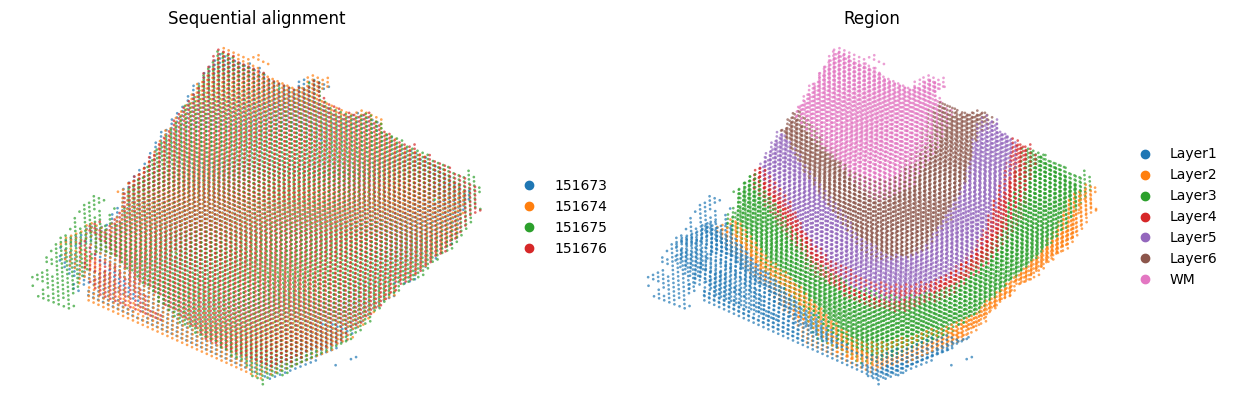

In [10]:
adata=sc.concat(sequential_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','Region'],title='Sequential alignment',size=15,alpha=0.7,frameon=False)

## <span style="color:black; font-weight:bold;">Reference align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'reference' The slices are aligned to the reference target
+ ref_idx: Reference target, the other slices are aligned to the target slice

### <span style="color:black; font-weight:bold;">Output</span>   
reference_list: A list of slices after reference align

In [8]:
reference_list = Multi_slices_rigid_alignment(adata_list, mode='reference', ref_idx=3, epochs=500, sample_size=1000, enable_scale=False, device=device)


--- Aligning Slice 1 to Reference (Slice 4) ---
Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████████| 500/500 [00:00<00:00, 591.29it/s, Loss=114.58, Scale=1.000, Rot=-46.79°, Trans=(521.0, -5181.9)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -46.87°, Translation (x, y): (520.93, -5183.04)

--- Aligning Slice 2 to Reference (Slice 4) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 500/500 [00:00<00:00, 653.28it/s, Loss=117.67, Scale=1.000, Rot=117.74°, Trans=(8212.2, -6631.7)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 117.88°, Translation (x, y): (8210.50, -6632.44)

--- Aligning Slice 3 to Reference (Slice 4) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 500/500 [00:00<00:00, 566.74it/s, Loss=136.28, Scale=1.000, Rot=-94.92°, Trans=(7648.6, -5473.6)]

Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -96.48°, Translation (x, y): (7648.57, -5474.93)

--- Slice 4 is the reference, skipping ---

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">Spatial mapping of the reference alignment result for DLPFC</span>

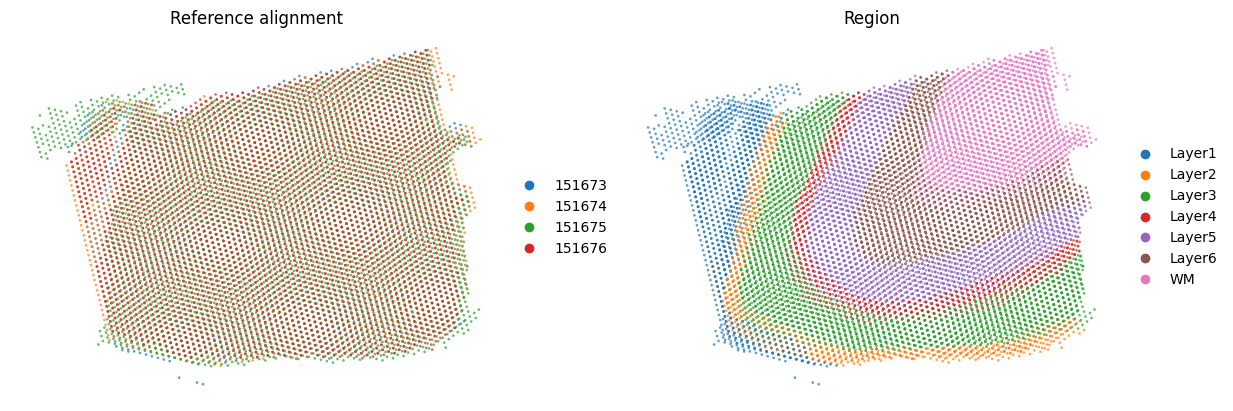

In [11]:
adata=sc.concat(reference_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','Region'],title='Reference alignment',size=15,alpha=0.7,frameon=False)